# 04 — Vision Transformer (DeiT-Small, full fine-tuning)

ImageNet-pretrained DeiT-Small at 224×224. Phase 1 warms up the head; **phase 2 fully
fine-tunes the whole network** (ViTs transfer poorly with a frozen backbone on small
SAR data). Outputs are written to `results/vit/`.
*Requires `01_eda.ipynb` outputs.*

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
# Make the project root importable whether run from notebooks/ or the project root.
cwd = os.getcwd()
ROOT = cwd if os.path.isdir(os.path.join(cwd, "src")) else os.path.dirname(cwd)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
from src.dataset import PROJECT_ROOT
from src.evaluate import seed_everything
from IPython.display import Image, display, Markdown
seed_everything(42)

import torch
from src.dataset import CLASSES, DEIT_SIZE, DEIT_BATCH, NUM_WORKERS, make_loaders
from src.vit import (build_deit, set_phase1_trainable, set_phase2_trainable,
                     train_two_phase, predict, extract_deit_features)
from src.evaluate import (compute_metrics, save_confusion_matrix, count_params,
                          file_size_mb, measure_latency_ms, save_json, plot_training_curves)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
VIT_DIR = os.path.join(PROJECT_ROOT, "results", "vit")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
os.makedirs(VIT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
CKPT = os.path.join(MODELS_DIR, "deit_small_best.pth")
with open(os.path.join(PROJECT_ROOT, "results", "eda", "dataset_stats.json")) as f:
    stats = json.load(f)
mean, std = stats["pixel_mean"], stats["pixel_std"]
print(f"Device: {device} | AMP: {use_amp} | mean={mean:.4f} std={std:.4f}")

Device: cuda | AMP: True | mean=0.0295 std=0.0346


## Two-phase fine-tuning with full phase-2 FT (training, OOM batch fallback)

In [2]:
def attempt(batch_size):
    train_loader, val_loader, test_loader, dss = make_loaders(
        DEIT_SIZE, batch_size, NUM_WORKERS, mean=mean, std=std)
    model = build_deit(len(CLASSES)).to(device)
    t0 = time.perf_counter()
    history, phase_boundary = train_two_phase(
        model, train_loader, val_loader, device, CKPT,
        set_phase1_trainable, set_phase2_trainable,
        epochs_phase1=10, epochs_phase2=15, lr1=1e-3, lr2=5e-5, patience=7, use_amp=use_amp)
    return model, history, phase_boundary, time.perf_counter() - t0, test_loader, dss[2]

result, batch = None, None
for b in [DEIT_BATCH, 16, 8]:
    try:
        result = attempt(b); batch = b; break
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"CUDA OOM at batch={b}; retrying smaller.")
            if device.type == "cuda":
                torch.cuda.empty_cache()
            continue
        raise
model, history, phase_boundary, train_time, test_loader, test_ds = result
print(f"Trained DeiT-Small at batch size {batch} in {train_time:.1f}s")

[P1 01/10] lr=1.00e-03 train_loss=1.9454 val_loss=1.6989 train_acc=0.3316 val_acc=0.3777 best=0.3777 *


[P1 02/10] lr=1.00e-03 train_loss=1.5191 val_loss=1.3848 train_acc=0.5077 val_acc=0.5545 best=0.5545 *


[P1 03/10] lr=1.00e-03 train_loss=1.3155 val_loss=1.2709 train_acc=0.5668 val_acc=0.5884 best=0.5884 *


[P1 04/10] lr=1.00e-03 train_loss=1.2141 val_loss=1.2032 train_acc=0.6084 val_acc=0.5811 best=0.5884


[P1 05/10] lr=1.00e-03 train_loss=1.1244 val_loss=1.1144 train_acc=0.6444 val_acc=0.6368 best=0.6368 *


...

[P2 11/15] lr=1.25e-05 train_loss=0.0360 val_loss=0.1559 train_acc=0.9901 val_acc=0.9540 best=0.9613


[P2 12/15] lr=8.27e-06 train_loss=0.0339 val_loss=0.1351 train_acc=0.9906 val_acc=0.9516 best=0.9613


[P2 13/15] lr=4.77e-06 train_loss=0.0238 val_loss=0.1360 train_acc=0.9949 val_acc=0.9588 best=0.9613


[P2 14/15] lr=2.16e-06 train_loss=0.0244 val_loss=0.1331 train_acc=0.9940 val_acc=0.9588 best=0.9613


[P2 15/15] lr=5.46e-07 train_loss=0.0203 val_loss=0.1340 train_acc=0.9970 val_acc=0.9613 best=0.9613
Trained DeiT-Small at batch size 32 in 400.8s


## Evaluate the best checkpoint on the test set

In [3]:
model.load_state_dict(torch.load(CKPT, map_location=device))
y_true, y_pred, probs = predict(model, test_loader, device, use_amp)
feats, _ = extract_deit_features(model, test_loader, device, use_amp)
metrics = compute_metrics(y_true, y_pred, CLASSES)
total_params, _ = count_params(model)
set_phase2_trainable(model)
_, trainable_params = count_params(model)
latency = measure_latency_ms(model, test_ds, device)
model_size = file_size_mb(CKPT)
out = dict(metrics)
out.update({
    "model": "DeiT-Small", "feature_dim": 384, "train_time_sec": train_time,
    "inference_ms_per_image": latency, "model_size_mb": model_size,
    "total_params": total_params, "trainable_params": trainable_params,
    "phase_boundary": phase_boundary, "history": history,
    "best_val_acc": max(h["val_acc"] for h in history),
    "input_size": DEIT_SIZE, "batch_size": batch,
})
save_json(out, os.path.join(VIT_DIR, "vit_metrics.json"))
save_confusion_matrix(metrics["confusion_matrix"], CLASSES,
    f"DeiT-Small - Acc {metrics['accuracy']*100:.1f}%", os.path.join(VIT_DIR, "cm_vit.png"))
plot_training_curves(history, phase_boundary, "DeiT-Small - Training Curves",
    os.path.join(VIT_DIR, "vit_training_curves.png"))
np.savez(os.path.join(VIT_DIR, "vit_test_outputs.npz"),
         y_true=y_true, y_pred=y_pred, probs=probs, feats=feats)
print(f"Accuracy {metrics['accuracy']*100:.2f}%  Macro-F1 {metrics['macro_f1']*100:.2f}%")

Accuracy 95.79%  Macro-F1 95.03%


## Results

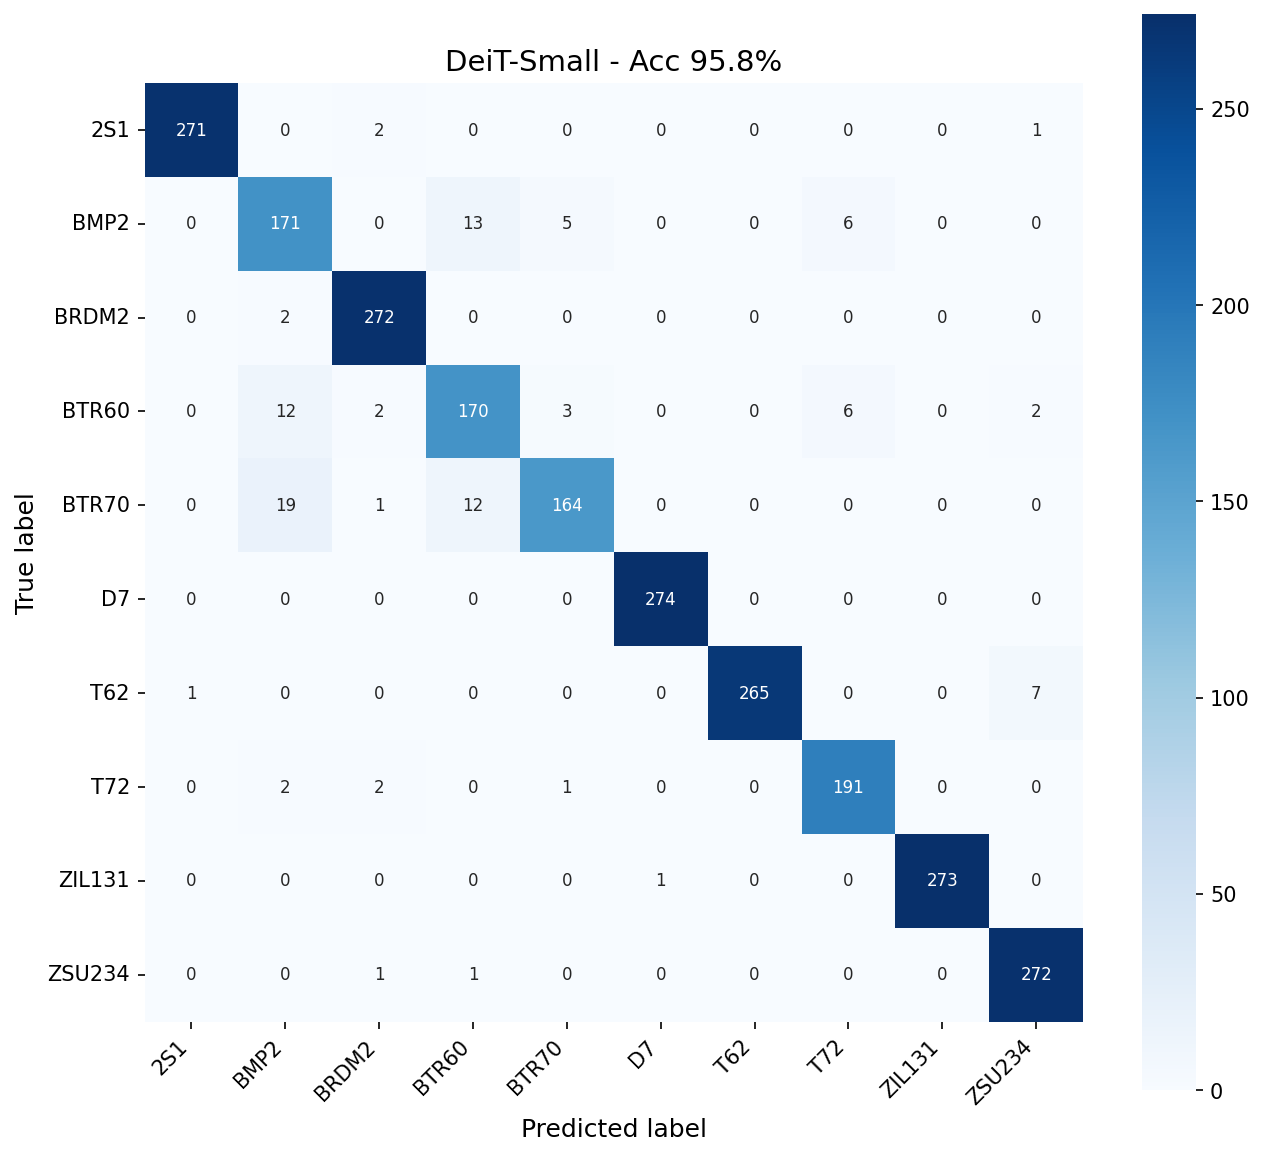

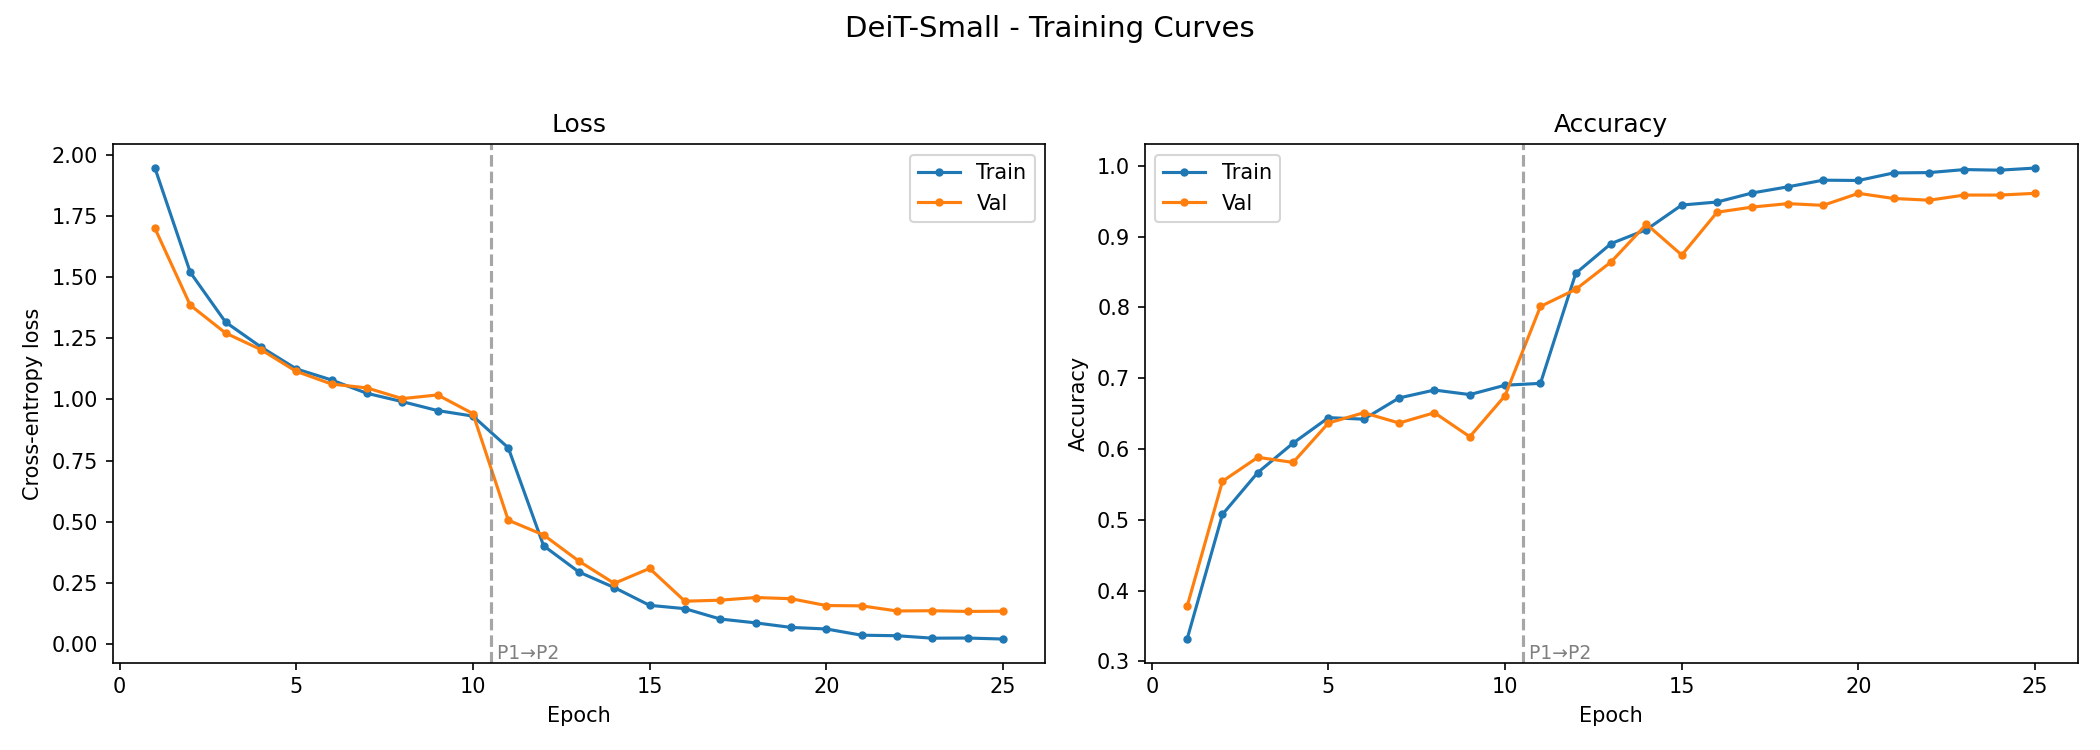

,DeiT-Small
Accuracy (%),95.79
Macro-F1 (%),95.03
Train time (s),400.80
Inference (ms/img),10.18
Model size (MB),82.70
Params (M),21.67


In [4]:
display(Image(filename=os.path.join(VIT_DIR, "cm_vit.png")))
display(Image(filename=os.path.join(VIT_DIR, "vit_training_curves.png")))
display(pd.DataFrame({"DeiT-Small": {
    "Accuracy (%)": round(metrics["accuracy"]*100, 2),
    "Macro-F1 (%)": round(metrics["macro_f1"]*100, 2),
    "Train time (s)": round(train_time, 1),
    "Inference (ms/img)": round(latency, 2),
    "Model size (MB)": round(model_size, 1),
    "Params (M)": round(total_params/1e6, 2),
}}))